# Audio Classification Using CNN

### Import Required Libraries

In [1]:
import os
import io
import math
import random
import zipfile
import urllib.request
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
import librosa
import librosa.display
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
 
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

### Dataset

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


In [3]:
DATA_DIR = "./ESC-50-master"
ZIP_URL = "https://github.com/karolpiczak/ESC-50/archive/master.zip"
ZIP_PATH = "./ESC-50-master.zip"

In [4]:
if not os.path.isdir(DATA_DIR):
    print("Downloading ESC-50 (~600MB)... this can take a few minutes.")
    urllib.request.urlretrieve(ZIP_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(".")
    print("Done extracting.")
else:
    print("ESC-50 already present, skipping download.")
 
AUDIO_DIR = os.path.join(DATA_DIR, "audio")
META_PATH = os.path.join(DATA_DIR, "meta", "esc50.csv")

ESC-50 already present, skipping download.


### Part A: Audio Classsification Without Augmentation

### Step1: Dataset Study

In [5]:
meta = pd.read_csv(META_PATH)
meta.head()

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [6]:
num_classes = meta["category"].nunique()
samples_per_class = meta.groupby("category")["filename"].count()
total_duration_sec = len(meta) * 5.0  # every ESC-50 clip is exactly 5 seconds
orig_sample_rate = 44100  # ESC-50 native sample rate

In [7]:
print(f"Number of classes       : {num_classes}")
print(f"Total samples           : {len(meta)}")
print(f"Samples per class (min/max/mean): "
      f"{samples_per_class.min()} / {samples_per_class.max()} / {samples_per_class.mean():.1f}")
print(f"Total duration           : {total_duration_sec/60:.1f} minutes")
print(f"Original sample rate     : {orig_sample_rate} Hz")

Number of classes       : 50
Total samples           : 2000
Samples per class (min/max/mean): 40 / 40 / 40.0
Total duration           : 166.7 minutes
Original sample rate     : 44100 Hz


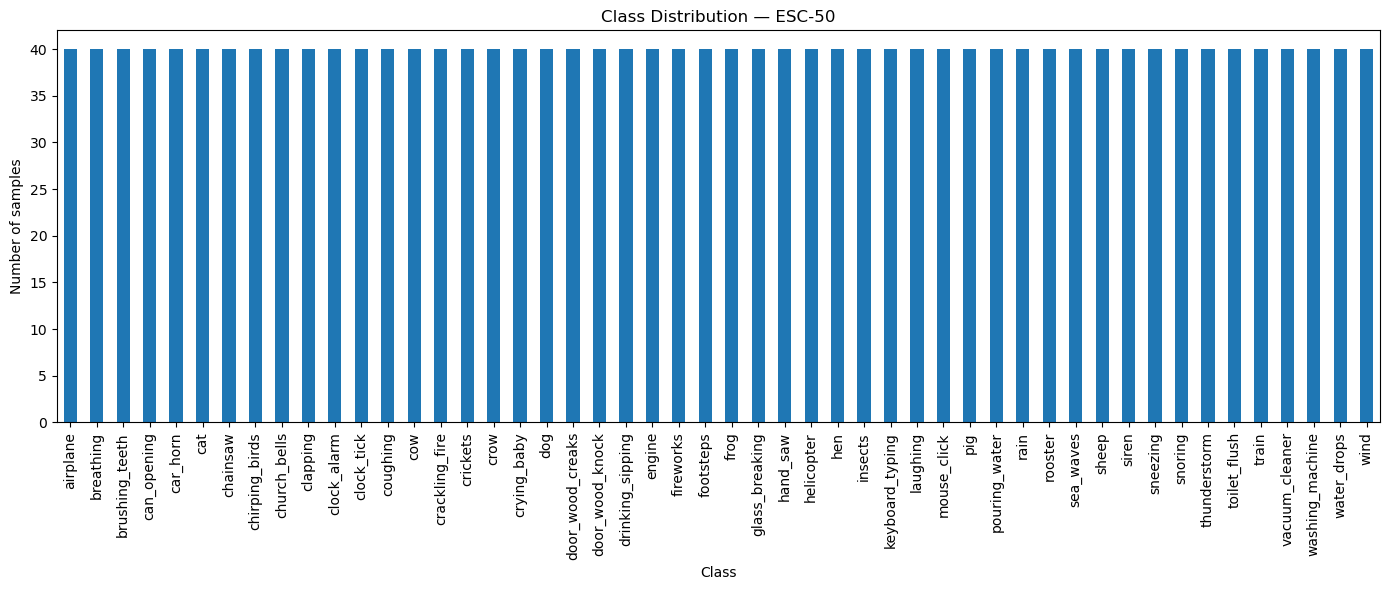

In [8]:
# Class distribution bar chart
plt.figure(figsize=(14, 6))
samples_per_class.sort_values(ascending=False).plot(kind="bar")
plt.title("Class Distribution — ESC-50")
plt.ylabel("Number of samples")
plt.xlabel("Class")
plt.tight_layout()
plt.savefig("step1_class_distribution.png", dpi=150)
plt.show()

In [9]:
classes_sorted = sorted(meta["category"].unique())

In [10]:
def load_one_example(category):
    row = meta[meta["category"] == category].iloc[0]
    path = os.path.join(AUDIO_DIR, row["filename"])
    y, sr = librosa.load(path, sr=None)  # keep native sr for this exploratory step
    return y, sr, row["filename"]

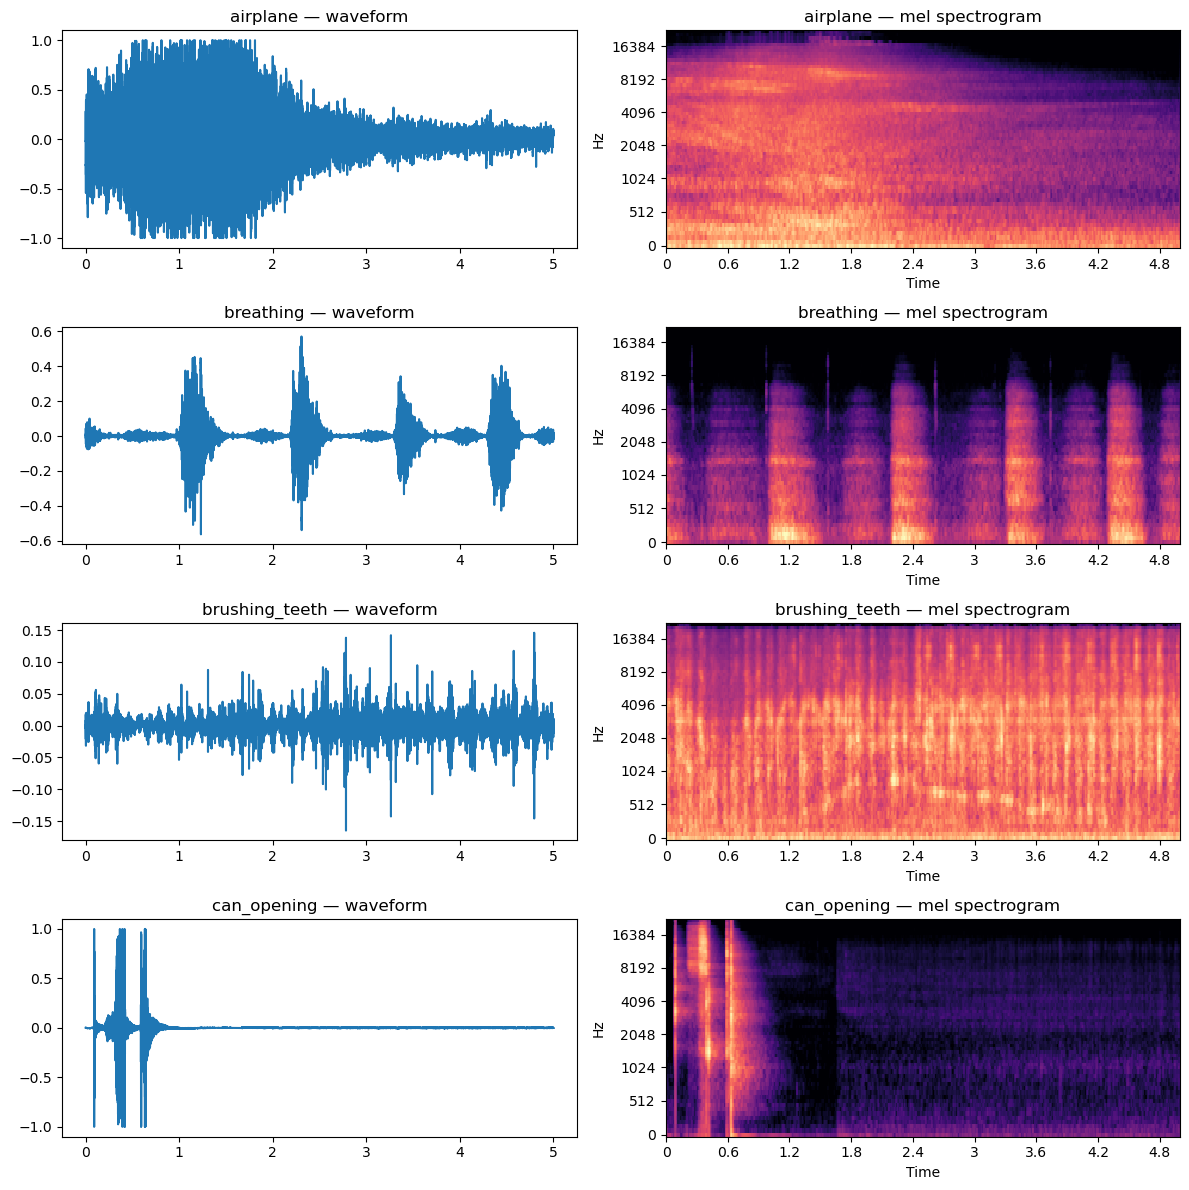

In [11]:
preview_classes = classes_sorted[:4]
fig, axes = plt.subplots(len(preview_classes), 2, figsize=(12, 3 * len(preview_classes)))
for i, cls in enumerate(preview_classes):
    y, sr, fname = load_one_example(cls)
    axes[i, 0].plot(np.linspace(0, len(y) / sr, len(y)), y)
    axes[i, 0].set_title(f"{cls} — waveform")
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    S_db = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[i, 1])
    axes[i, 1].set_title(f"{cls} — mel spectrogram")
plt.tight_layout()
plt.show()

### Audio Preprocessing

In [12]:
class AudioPreprocessor:
    def __init__(self, sr=16000, n_mels=64, n_fft=1024, hop_length=512, target_duration=4.0):
        self.sr = sr
        self.n_mels = n_mels
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.target_duration = target_duration
        self.target_samples = int(sr * target_duration)
 
    def load_and_resample(self, path):
        y, orig_sr = librosa.load(path, sr=None, mono=True)
        if orig_sr != self.sr:
            y = librosa.resample(y, orig_sr=orig_sr, target_sr=self.sr)
        return y
 
    def pad_or_truncate(self, y):
        if len(y) < self.target_samples:
            pad_width = self.target_samples - len(y)
            y = np.pad(y, (0, pad_width), mode="constant")
        else:
            y = y[: self.target_samples]
        return y
 
    def extract_mel_spectrogram(self, y):
        S = librosa.feature.melspectrogram(
            y=y, sr=self.sr, n_fft=self.n_fft,
            hop_length=self.hop_length, n_mels=self.n_mels
        )
        log_S = librosa.power_to_db(S, ref=np.max)
        # normalize to zero mean / unit std for stable training
        log_S = (log_S - log_S.mean()) / (log_S.std() + 1e-6)
        return log_S[np.newaxis, :, :].astype(np.float32)  # (1, n_mels, n_frames)
 
    def process(self, path):
        y = self.load_and_resample(path)
        y = self.pad_or_truncate(y)
        spec = self.extract_mel_spectrogram(y)
        return spec

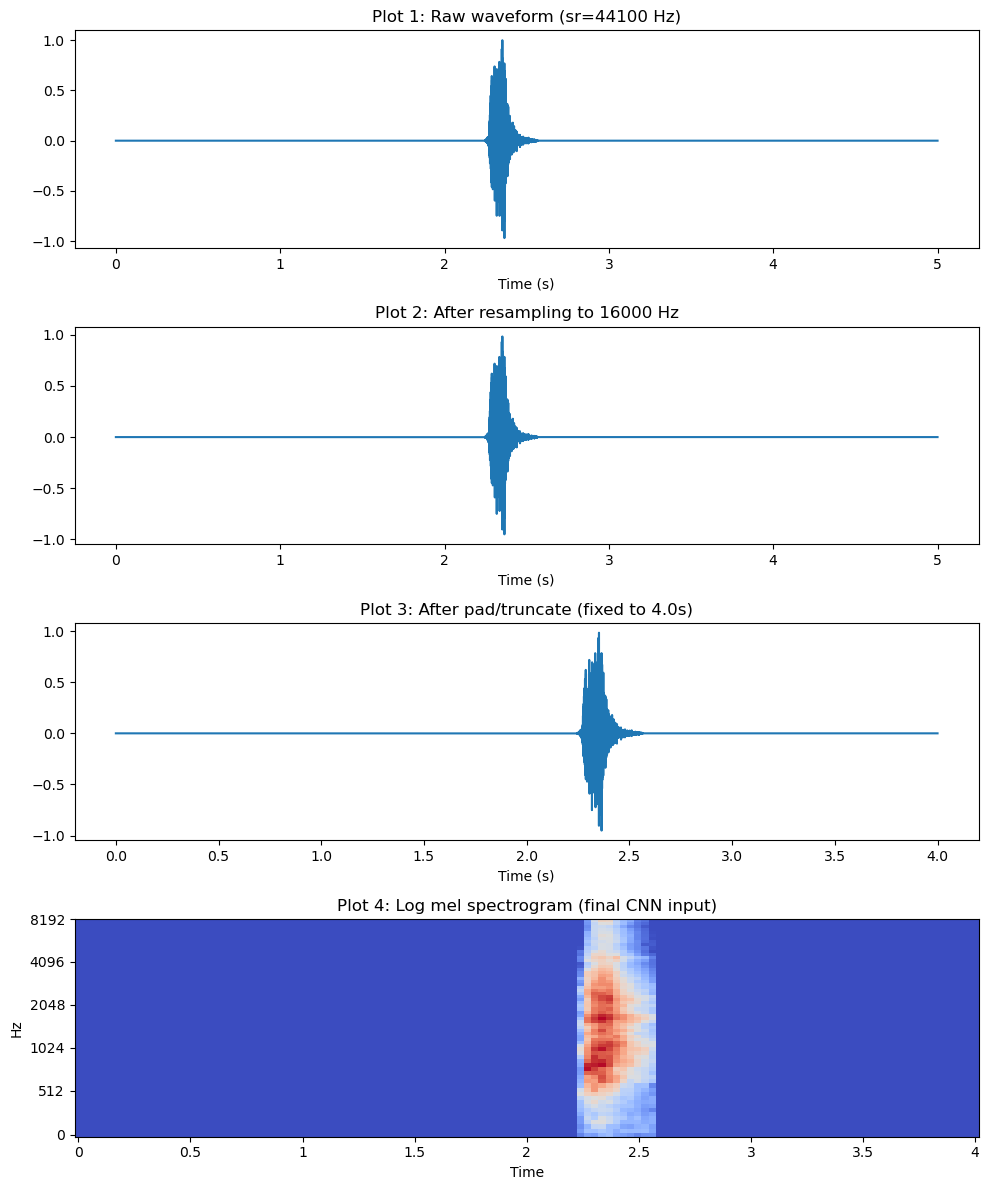

Final CNN input shape: (1, 64, 126)


In [13]:
prep = AudioPreprocessor()
example_path = os.path.join(AUDIO_DIR, meta.iloc[0]["filename"])
 
y_raw, orig_sr = librosa.load(example_path, sr=None, mono=True)
y_resampled = prep.load_and_resample(example_path)
y_fixed = prep.pad_or_truncate(y_resampled)
spec = prep.extract_mel_spectrogram(y_fixed)
 
fig, axes = plt.subplots(4, 1, figsize=(10, 12))
 
axes[0].plot(np.linspace(0, len(y_raw) / orig_sr, len(y_raw)), y_raw)
axes[0].set_title(f"Plot 1: Raw waveform (sr={orig_sr} Hz)")
axes[0].set_xlabel("Time (s)")
 
axes[1].plot(np.linspace(0, len(y_resampled) / prep.sr, len(y_resampled)), y_resampled)
axes[1].set_title(f"Plot 2: After resampling to {prep.sr} Hz")
axes[1].set_xlabel("Time (s)")
 
axes[2].plot(np.linspace(0, len(y_fixed) / prep.sr, len(y_fixed)), y_fixed)
axes[2].set_title(f"Plot 3: After pad/truncate (fixed to {prep.target_duration}s)")
axes[2].set_xlabel("Time (s)")
 
librosa.display.specshow(spec[0], sr=prep.sr, hop_length=prep.hop_length,
                          x_axis="time", y_axis="mel", ax=axes[3])
axes[3].set_title("Plot 4: Log mel spectrogram (final CNN input)")
 
plt.tight_layout()
plt.savefig("step2_preprocessing_pipeline.png", dpi=150)
plt.show()
 
print("Final CNN input shape:", spec.shape)

### Step 3: Dataset and DataLoader

In [14]:
label_encoder = {cls: i for i, cls in enumerate(sorted(meta["category"].unique()))}
idx_to_label = {v: k for k, v in label_encoder.items()}
meta["label"] = meta["category"].map(label_encoder)

In [15]:
class AudioDataset(Dataset):
    def __init__(self, file_list, labels, preprocessor, augment=None):
        """
        file_list: list of audio file paths
        labels: list of integer labels
        preprocessor: AudioPreprocessor instance
        augment: optional augmentation (None for Part A)
        """
        self.file_list = file_list
        self.labels = labels
        self.preprocessor = preprocessor
        self.augment = augment
 
    def __len__(self):
        return len(self.file_list)
 
    def __getitem__(self, idx):
        """
        1. Preprocess audio -> log mel spectrogram
        2. Apply augmentation if provided (Part B only)
        3. Return (spectrogram_tensor, label)
        """
        path = self.file_list[idx]
        spec = self.preprocessor.process(path)
        spec = torch.from_numpy(spec)
        if self.augment is not None:
            spec = self.augment(spec)
        label = self.labels[idx]
        return spec, label

In [21]:
meta["path"] = meta["filename"].apply(lambda f: os.path.join(AUDIO_DIR, f))
 
train_df = meta[meta["fold"].isin([1, 2, 3])]
val_df   = meta[meta["fold"] == 4]
test_df  = meta[meta["fold"] == 5]
 
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
 
preprocessor = AudioPreprocessor(sr=16000, n_mels=64, n_fft=1024, hop_length=512, target_duration=4.0)
 
train_ds_A = AudioDataset(train_df["path"].tolist(), train_df["label"].tolist(), preprocessor, augment=None)
val_ds     = AudioDataset(val_df["path"].tolist(),   val_df["label"].tolist(),   preprocessor, augment=None)
test_ds    = AudioDataset(test_df["path"].tolist(),  test_df["label"].tolist(),  preprocessor, augment=None)
 
BATCH_SIZE = 32
train_loader_A = DataLoader(train_ds_A, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader     = DataLoader(val_ds,     batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader    = DataLoader(test_ds,    batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
 

Train: 1200  Val: 400  Test: 400


### Step 4: CNN Model Architecture

In [22]:
class AudioCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(128, num_classes)
 
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.global_pool(x)          # (B, 128, 1, 1)
        x = x.flatten(1)                 # (B, 128)
        x = self.dropout(x)
        x = self.fc(x)                   # (B, num_classes)
        return x

### Step 5: Training Without Augmentation (Part A)

In [23]:
def train_model(model, train_loader, val_loader, num_epochs=30, lr=1e-3, tag="A"):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)
 
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
 
    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for specs, labels in train_loader:
            specs, labels = specs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(specs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
 
            running_loss += loss.item() * specs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
 
        train_loss = running_loss / total
        train_acc = correct / total
 
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for specs, labels in val_loader:
                specs, labels = specs.to(DEVICE), labels.to(DEVICE)
                outputs = model(specs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * specs.size(0)
                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        val_loss /= val_total
        val_acc = val_correct / val_total
        scheduler.step(val_loss)
 
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
 
        print(f"[{tag}] Epoch {epoch+1}/{num_epochs} "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
 
    return model, history

In [24]:
NUM_EPOCHS = 30
model_A = AudioCNN(num_classes=num_classes)
model_A, history_A = train_model(model_A, train_loader_A, val_loader, num_epochs=NUM_EPOCHS, tag="A")

[A] Epoch 1/30 train_loss=3.7480 train_acc=0.0583 val_loss=3.5114 val_acc=0.0900
[A] Epoch 2/30 train_loss=3.3007 train_acc=0.1708 val_loss=3.1431 val_acc=0.2175
[A] Epoch 3/30 train_loss=2.9899 train_acc=0.2383 val_loss=2.8220 val_acc=0.2950
[A] Epoch 4/30 train_loss=2.7091 train_acc=0.2925 val_loss=2.6155 val_acc=0.4075
[A] Epoch 5/30 train_loss=2.4829 train_acc=0.3675 val_loss=2.3845 val_acc=0.4075
[A] Epoch 6/30 train_loss=2.2792 train_acc=0.3992 val_loss=2.1943 val_acc=0.4375
[A] Epoch 7/30 train_loss=2.1471 train_acc=0.4258 val_loss=2.0950 val_acc=0.4700
[A] Epoch 8/30 train_loss=2.0045 train_acc=0.4750 val_loss=2.0022 val_acc=0.4725
[A] Epoch 9/30 train_loss=1.8690 train_acc=0.5333 val_loss=1.8677 val_acc=0.5100
[A] Epoch 10/30 train_loss=1.7657 train_acc=0.5267 val_loss=1.7927 val_acc=0.5025
[A] Epoch 11/30 train_loss=1.6879 train_acc=0.5492 val_loss=1.7573 val_acc=0.5275
[A] Epoch 12/30 train_loss=1.5778 train_acc=0.5817 val_loss=1.7072 val_acc=0.5425
[A] Epoch 13/30 train_los

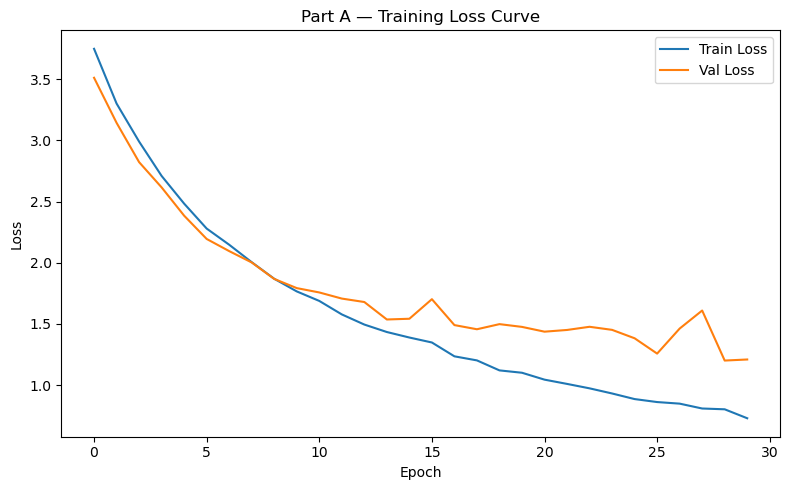

In [25]:
# Training loss curve
plt.figure(figsize=(8, 5))
plt.plot(history_A["train_loss"], label="Train Loss")
plt.plot(history_A["val_loss"], label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Part A — Training Loss Curve")
plt.legend(); plt.tight_layout()
plt.savefig("stepA5_loss_curve.png", dpi=150)
plt.show()

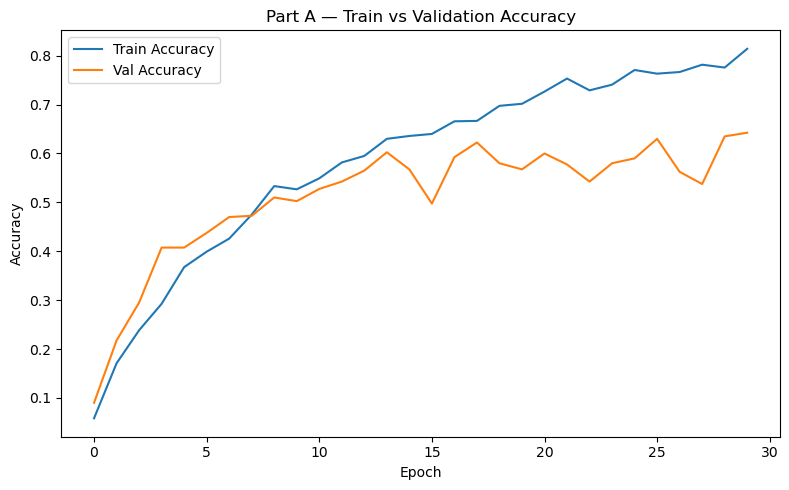

In [26]:
# Train vs val accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_A["train_acc"], label="Train Accuracy")
plt.plot(history_A["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("Part A — Train vs Validation Accuracy")
plt.legend(); plt.tight_layout()
plt.savefig("stepA5_accuracy_curve.png", dpi=150)
plt.show()

### Step 6: Evaluation Without Augmentation 

In [27]:
def evaluate_model(model, loader, idx_to_label, tag="A"):
    model.eval()
    all_preds, all_labels, all_specs = [], [], []
    with torch.no_grad():
        for specs, labels in loader:
            specs_dev = specs.to(DEVICE)
            outputs = model(specs_dev)
            preds = outputs.argmax(dim=1).cpu()
            all_preds.append(preds)
            all_labels.append(labels)
            all_specs.append(specs)
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_specs = torch.cat(all_specs).numpy()
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )
    print(f"[{tag}] Test Accuracy       : {acc:.4f}")
    print(f"[{tag}] Macro Precision     : {precision:.4f}")
    print(f"[{tag}] Macro Recall        : {recall:.4f}")
    print(f"[{tag}] Macro F1-score      : {f1:.4f}")
    label_names = [idx_to_label[i] for i in range(len(idx_to_label))]
    report = classification_report(all_labels, all_preds, target_names=label_names,
                                    zero_division=0, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    print(report_df)
    cm = confusion_matrix(all_labels, all_preds)
    results = {
        "accuracy": acc, "precision": precision, "recall": recall, "f1": f1,
        "cm": cm, "report_df": report_df,
        "preds": all_preds, "labels": all_labels, "specs": all_specs,
    }
    return results

In [28]:
results_A = evaluate_model(model_A, test_loader, idx_to_label, tag="A")

[A] Test Accuracy       : 0.5525
[A] Macro Precision     : 0.5933
[A] Macro Recall        : 0.5525
[A] Macro F1-score      : 0.5281
                  precision  recall  f1-score   support
airplane           0.125000  0.1250  0.125000    8.0000
breathing          0.500000  0.1250  0.200000    8.0000
brushing_teeth     0.875000  0.8750  0.875000    8.0000
can_opening        0.285714  0.2500  0.266667    8.0000
car_horn           0.500000  0.3750  0.428571    8.0000
cat                0.666667  0.7500  0.705882    8.0000
chainsaw           0.538462  0.8750  0.666667    8.0000
chirping_birds     0.666667  0.7500  0.705882    8.0000
church_bells       1.000000  1.0000  1.000000    8.0000
clapping           0.272727  0.3750  0.315789    8.0000
clock_alarm        1.000000  0.6250  0.769231    8.0000
clock_tick         0.500000  0.5000  0.500000    8.0000
coughing           0.400000  0.7500  0.521739    8.0000
cow                0.857143  0.7500  0.800000    8.0000
crackling_fire     0.250000 

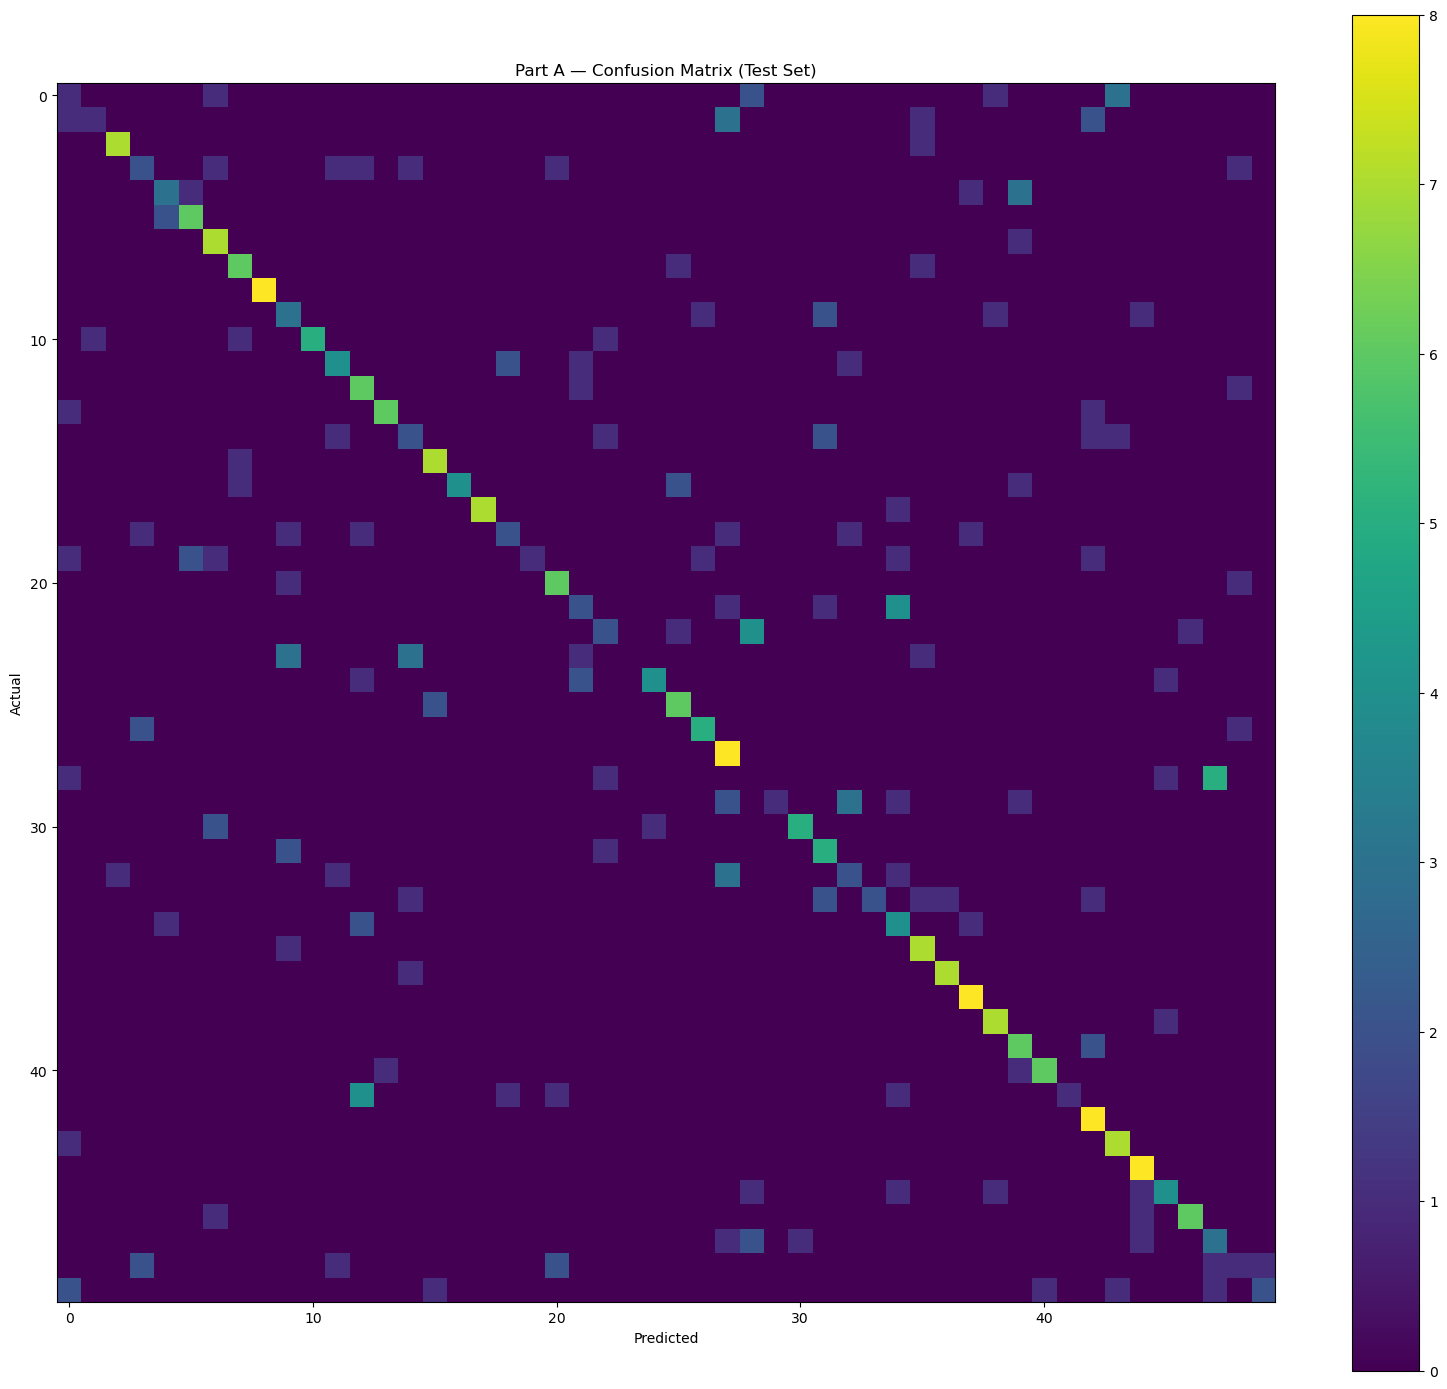

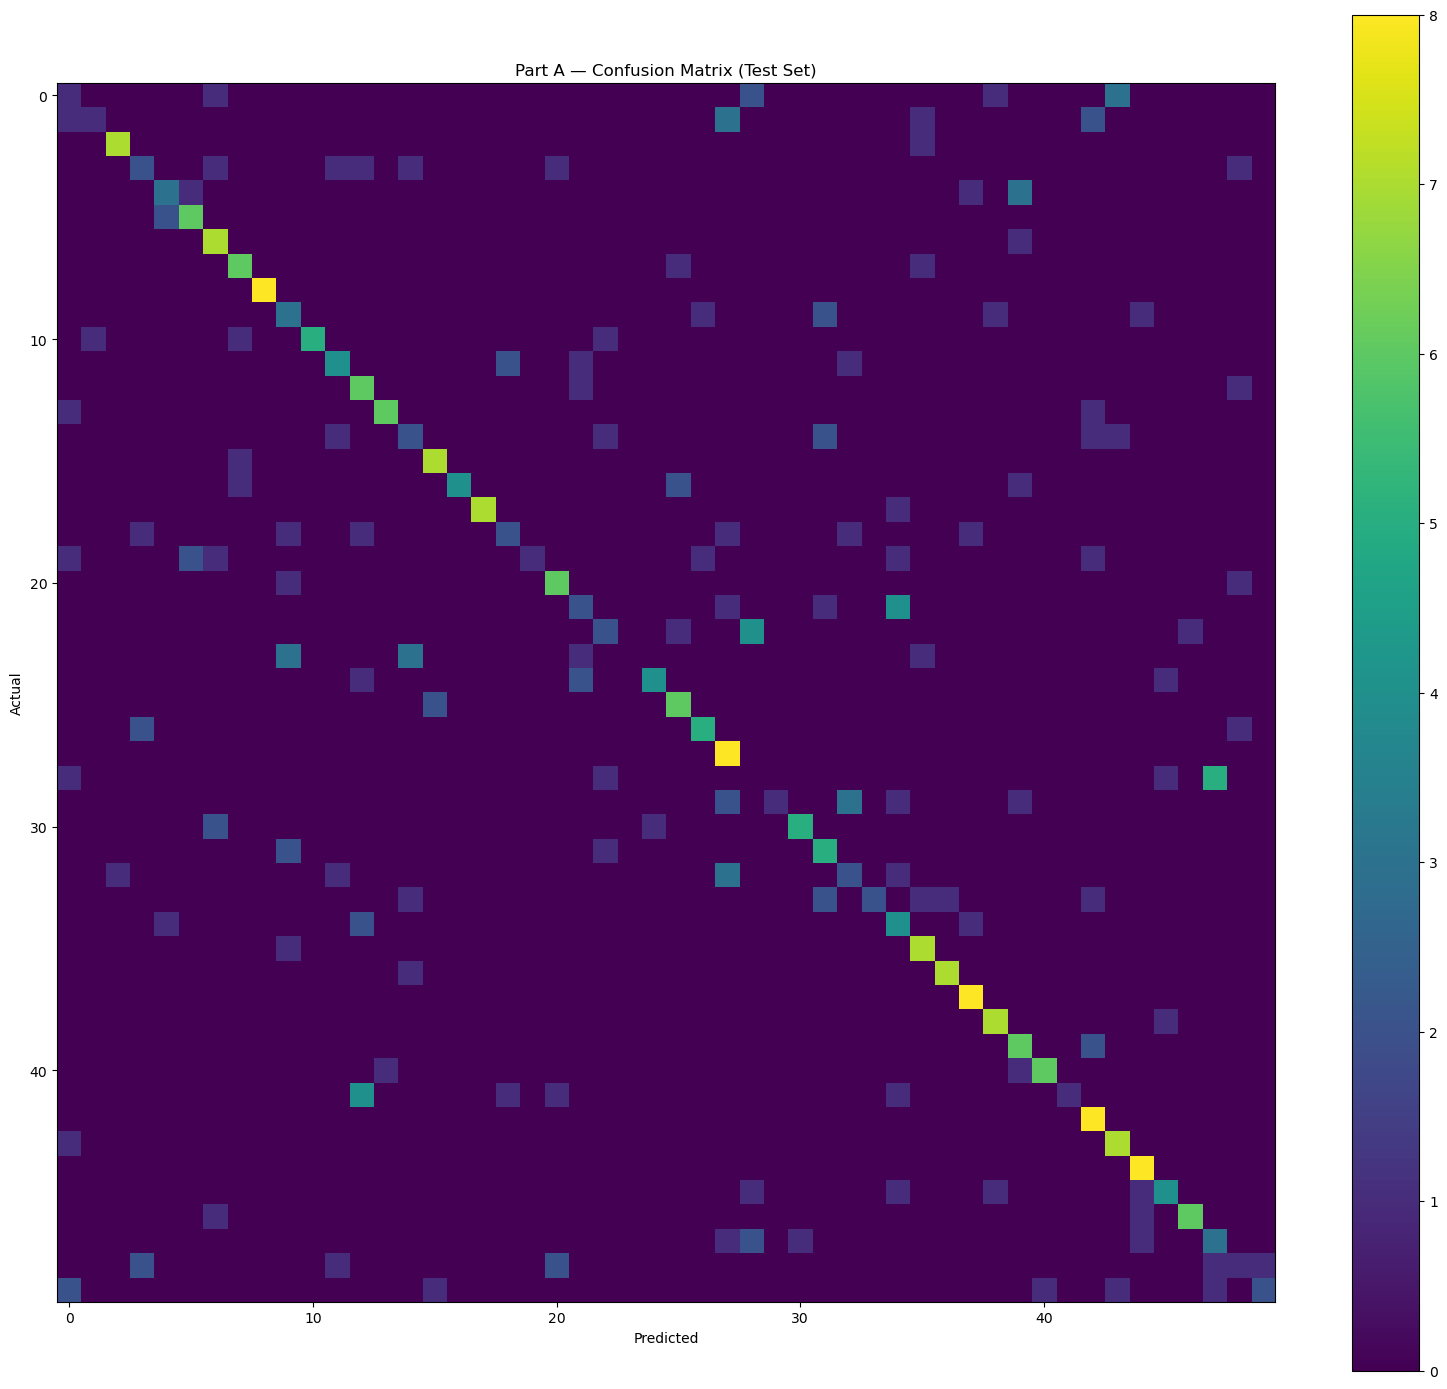

In [29]:
# Confusion matrix (large: 50x50) - plotted as heatmap, saved to file
plt.figure(figsize=(16, 14))
plt.imshow(results_A["cm"], cmap="viridis")
plt.title("Part A — Confusion Matrix (Test Set)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.colorbar()
plt.tight_layout()
plt.savefig("stepA6_confusion_matrix.png", dpi=150)
plt.show()# Confusion matrix (large: 50x50) - plotted as heatmap, saved to file
plt.figure(figsize=(16, 14))
plt.imshow(results_A["cm"], cmap="viridis")
plt.title("Part A — Confusion Matrix (Test Set)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.colorbar()
plt.tight_layout()
plt.savefig("stepA6_confusion_matrix.png", dpi=150)
plt.show()

In [30]:
results_A["report_df"].to_csv("stepA6_classification_report.csv")

In [31]:
# 3 correct + 3 incorrect predictions with spectrograms
def show_predictions(results, idx_to_label, tag="A", n=3):
    preds, labels, specs = results["preds"], results["labels"], results["specs"]
    correct_idx = np.where(preds == labels)[0]
    incorrect_idx = np.where(preds != labels)[0]
 
    chosen_correct = np.random.choice(correct_idx, size=min(n, len(correct_idx)), replace=False)
    chosen_incorrect = np.random.choice(incorrect_idx, size=min(n, len(incorrect_idx)), replace=False)
 
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
    for i, idx in enumerate(chosen_correct):
        librosa.display.specshow(specs[idx, 0], sr=16000, x_axis="time", y_axis="mel", ax=axes[0, i])
        axes[0, i].set_title(f"Correct\nPred: {idx_to_label[preds[idx]]}", fontsize=9)
    for i, idx in enumerate(chosen_incorrect):
        librosa.display.specshow(specs[idx, 0], sr=16000, x_axis="time", y_axis="mel", ax=axes[1, i])
        axes[1, i].set_title(
            f"Incorrect\nPred: {idx_to_label[preds[idx]]} / Actual: {idx_to_label[labels[idx]]}",
            fontsize=9
        )
    plt.tight_layout()
    plt.savefig(f"step{tag}6_sample_predictions.png", dpi=150)
    plt.show()

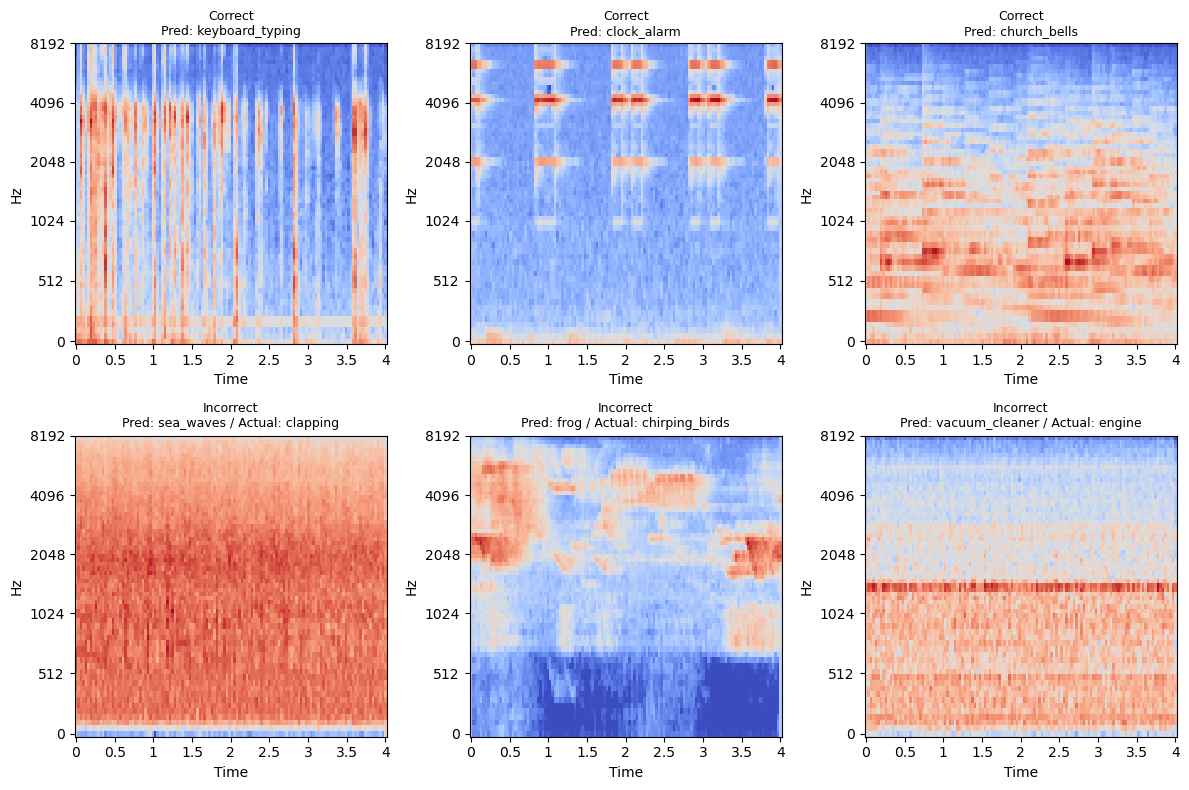

In [32]:
show_predictions(results_A, idx_to_label, tag="A")

### Part B : Audio Classification With SpecAugment

### Step 7: Implement SpecAugment

In [33]:
class SpecAugment:
    def __init__(self, freq_mask_param=15, time_mask_param=35,
                 num_freq_masks=2, num_time_masks=2):
        self.F = freq_mask_param
        self.T = time_mask_param
        self.num_freq_masks = num_freq_masks
        self.num_time_masks = num_time_masks
 
    def freq_mask(self, spec):
        num_mels = spec.shape[1]
        f = random.randint(0, self.F)
        if f == 0 or f >= num_mels:
            return spec
        f0 = random.randint(0, num_mels - f)
        spec[:, f0:f0 + f, :] = 0
        return spec
 
    def time_mask(self, spec):
        num_frames = spec.shape[2]
        t = random.randint(0, self.T)
        if t == 0 or t >= num_frames:
            return spec
        t0 = random.randint(0, num_frames - t)
        spec[:, :, t0:t0 + t] = 0
        return spec
 
    def __call__(self, spec):
        spec = spec.clone()
        for _ in range(self.num_freq_masks):
            spec = self.freq_mask(spec)
        for _ in range(self.num_time_masks):
            spec = self.time_mask(spec)
        return spec

### Step 8: Visualize SpecAugment

In [36]:
spec_augmenter = SpecAugment(freq_mask_param=15, time_mask_param=35,
                              num_freq_masks=1, num_time_masks=1)
example_spec = torch.from_numpy(prep.process(example_path))  # (1, n_mels, n_frames)
freq_only = spec_augmenter.freq_mask(example_spec.clone())
time_only = spec_augmenter.time_mask(example_spec.clone())
full_aug = SpecAugment(15, 35, 2, 2)(example_spec.clone())

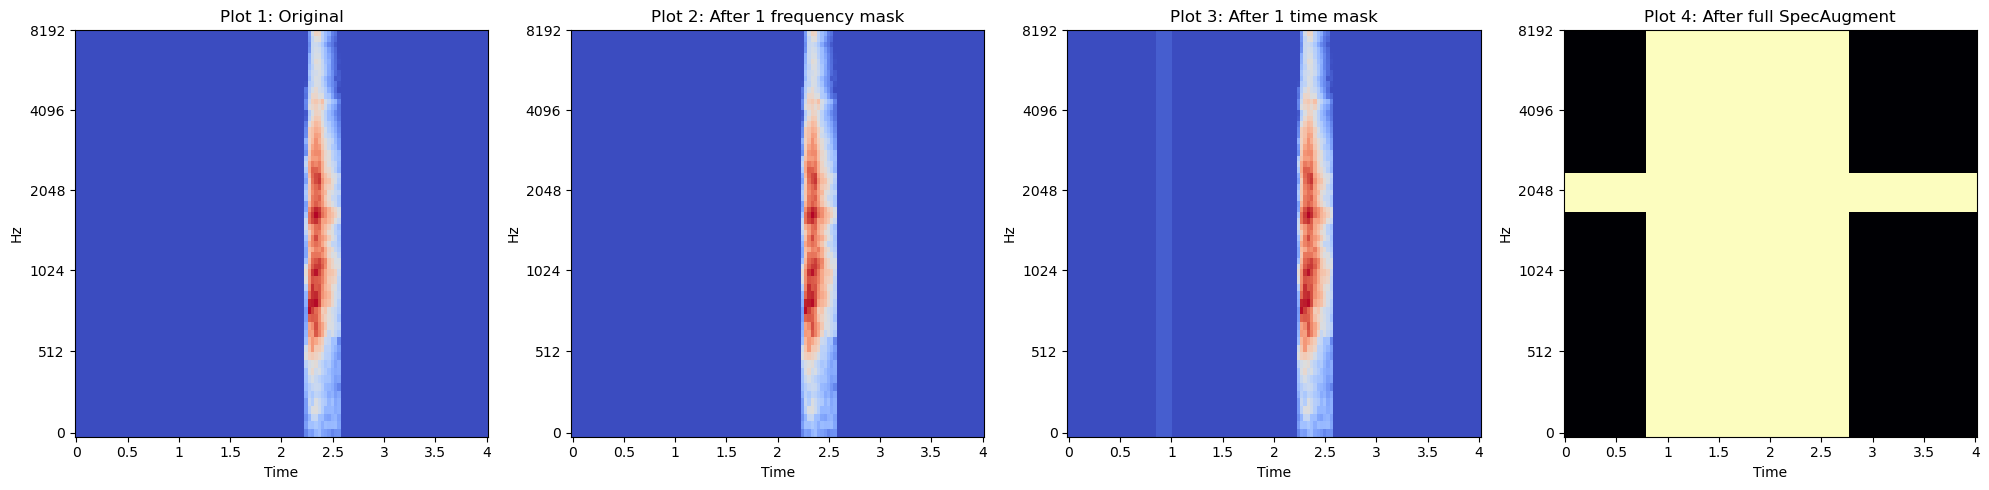

In [37]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
librosa.display.specshow(example_spec[0].numpy(), sr=16000, x_axis="time", y_axis="mel", ax=axes[0])
axes[0].set_title("Plot 1: Original")
librosa.display.specshow(freq_only[0].numpy(), sr=16000, x_axis="time", y_axis="mel", ax=axes[1])
axes[1].set_title("Plot 2: After 1 frequency mask")
librosa.display.specshow(time_only[0].numpy(), sr=16000, x_axis="time", y_axis="mel", ax=axes[2])
axes[2].set_title("Plot 3: After 1 time mask")
librosa.display.specshow(full_aug[0].numpy(), sr=16000, x_axis="time", y_axis="mel", ax=axes[3])
axes[3].set_title("Plot 4: After full SpecAugment")
plt.tight_layout()
plt.savefig("step8_specaugment_visualization.png", dpi=150)
plt.show()

In [38]:
# 2+ different random augmentations of the same sample
full_augmenter = SpecAugment(15, 35, 2, 2)
aug1 = full_augmenter(example_spec.clone())
aug2 = full_augmenter(example_spec.clone())

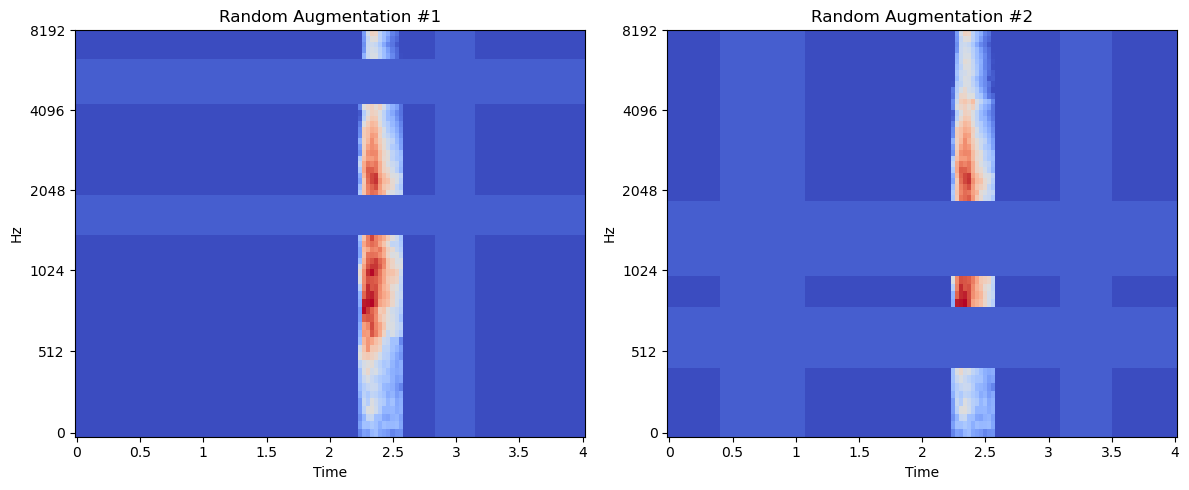

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
librosa.display.specshow(aug1[0].numpy(), sr=16000, x_axis="time", y_axis="mel", ax=axes[0])
axes[0].set_title("Random Augmentation #1")
librosa.display.specshow(aug2[0].numpy(), sr=16000, x_axis="time", y_axis="mel", ax=axes[1])
axes[1].set_title("Random Augmentation #2")
plt.tight_layout()
plt.savefig("step8_specaugment_two_random.png", dpi=150)
plt.show()

### Step 9: Training with SpecAugment

In [41]:
train_augment = SpecAugment(freq_mask_param=15, time_mask_param=35,
                             num_freq_masks=2, num_time_masks=2)
train_ds_B = AudioDataset(train_df["path"].tolist(), train_df["label"].tolist(),
                           preprocessor, augment=train_augment)
train_loader_B = DataLoader(train_ds_B, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

In [42]:
model_B = AudioCNN(num_classes=num_classes)
model_B, history_B = train_model(model_B, train_loader_B, val_loader, num_epochs=NUM_EPOCHS, tag="B")

[B] Epoch 1/30 train_loss=3.8711 train_acc=0.0408 val_loss=3.5821 val_acc=0.0975
[B] Epoch 2/30 train_loss=3.5968 train_acc=0.0833 val_loss=3.2214 val_acc=0.1575
[B] Epoch 3/30 train_loss=3.3588 train_acc=0.1142 val_loss=2.9213 val_acc=0.2275
[B] Epoch 4/30 train_loss=3.1678 train_acc=0.1683 val_loss=2.6737 val_acc=0.2875
[B] Epoch 5/30 train_loss=3.0312 train_acc=0.1867 val_loss=2.5761 val_acc=0.2875
[B] Epoch 6/30 train_loss=2.8528 train_acc=0.2392 val_loss=2.4141 val_acc=0.3500
[B] Epoch 7/30 train_loss=2.7494 train_acc=0.2592 val_loss=2.4008 val_acc=0.2925
[B] Epoch 8/30 train_loss=2.5875 train_acc=0.2983 val_loss=2.1872 val_acc=0.3850
[B] Epoch 9/30 train_loss=2.5011 train_acc=0.3017 val_loss=2.3075 val_acc=0.3025
[B] Epoch 10/30 train_loss=2.4665 train_acc=0.3258 val_loss=1.9906 val_acc=0.4375
[B] Epoch 11/30 train_loss=2.3211 train_acc=0.3433 val_loss=2.0119 val_acc=0.3850
[B] Epoch 12/30 train_loss=2.2817 train_acc=0.3700 val_loss=1.9012 val_acc=0.4550
[B] Epoch 13/30 train_los

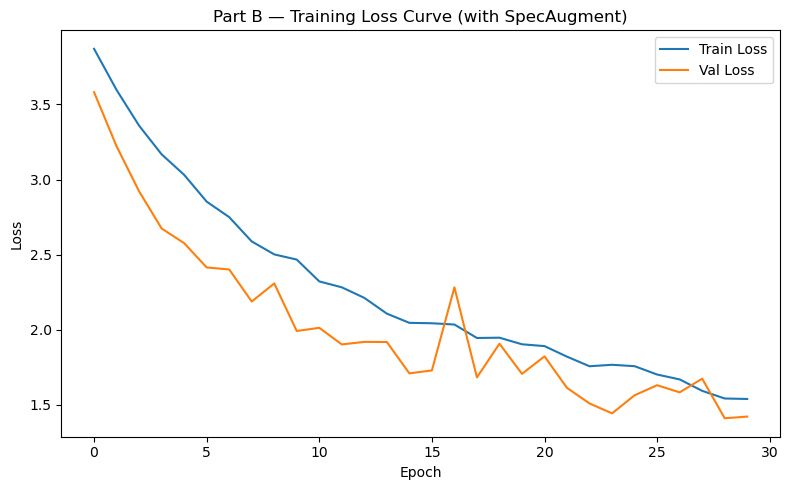

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(history_B["train_loss"], label="Train Loss")
plt.plot(history_B["val_loss"], label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Part B — Training Loss Curve (with SpecAugment)")
plt.legend(); plt.tight_layout()
plt.savefig("stepB9_loss_curve.png", dpi=150)
plt.show()

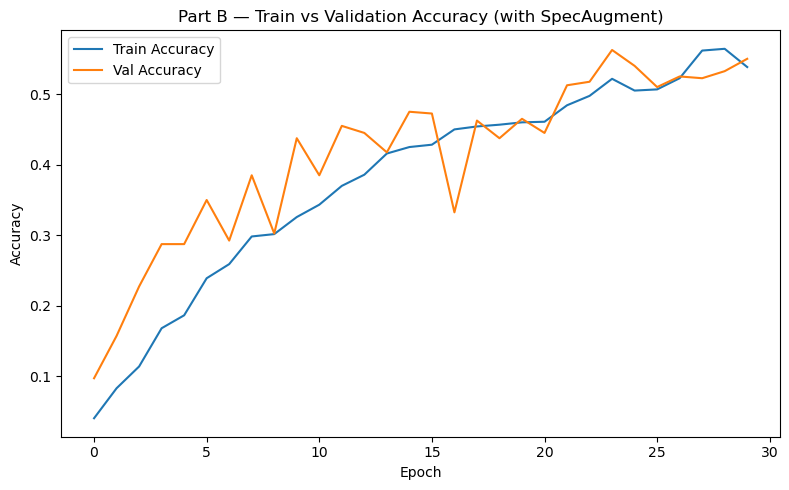

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(history_B["train_acc"], label="Train Accuracy")
plt.plot(history_B["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("Part B — Train vs Validation Accuracy (with SpecAugment)")
plt.legend(); plt.tight_layout()
plt.savefig("stepB9_accuracy_curve.png", dpi=150)
plt.show()

### Step 10: Evaluation with SpecAugment

In [45]:
results_B = evaluate_model(model_B, test_loader, idx_to_label, tag="B")

[B] Test Accuracy       : 0.5075
[B] Macro Precision     : 0.5299
[B] Macro Recall        : 0.5075
[B] Macro F1-score      : 0.4865
                  precision  recall  f1-score   support
airplane           0.333333  0.5000  0.400000    8.0000
breathing          0.500000  0.2500  0.333333    8.0000
brushing_teeth     1.000000  0.8750  0.933333    8.0000
can_opening        0.285714  0.2500  0.266667    8.0000
car_horn           0.250000  0.5000  0.333333    8.0000
cat                0.833333  0.6250  0.714286    8.0000
chainsaw           0.500000  0.7500  0.600000    8.0000
chirping_birds     0.714286  0.6250  0.666667    8.0000
church_bells       0.533333  1.0000  0.695652    8.0000
clapping           0.250000  0.2500  0.250000    8.0000
clock_alarm        0.857143  0.7500  0.800000    8.0000
clock_tick         0.571429  0.5000  0.533333    8.0000
coughing           0.250000  0.1250  0.166667    8.0000
cow                0.400000  1.0000  0.571429    8.0000
crackling_fire     0.666667 

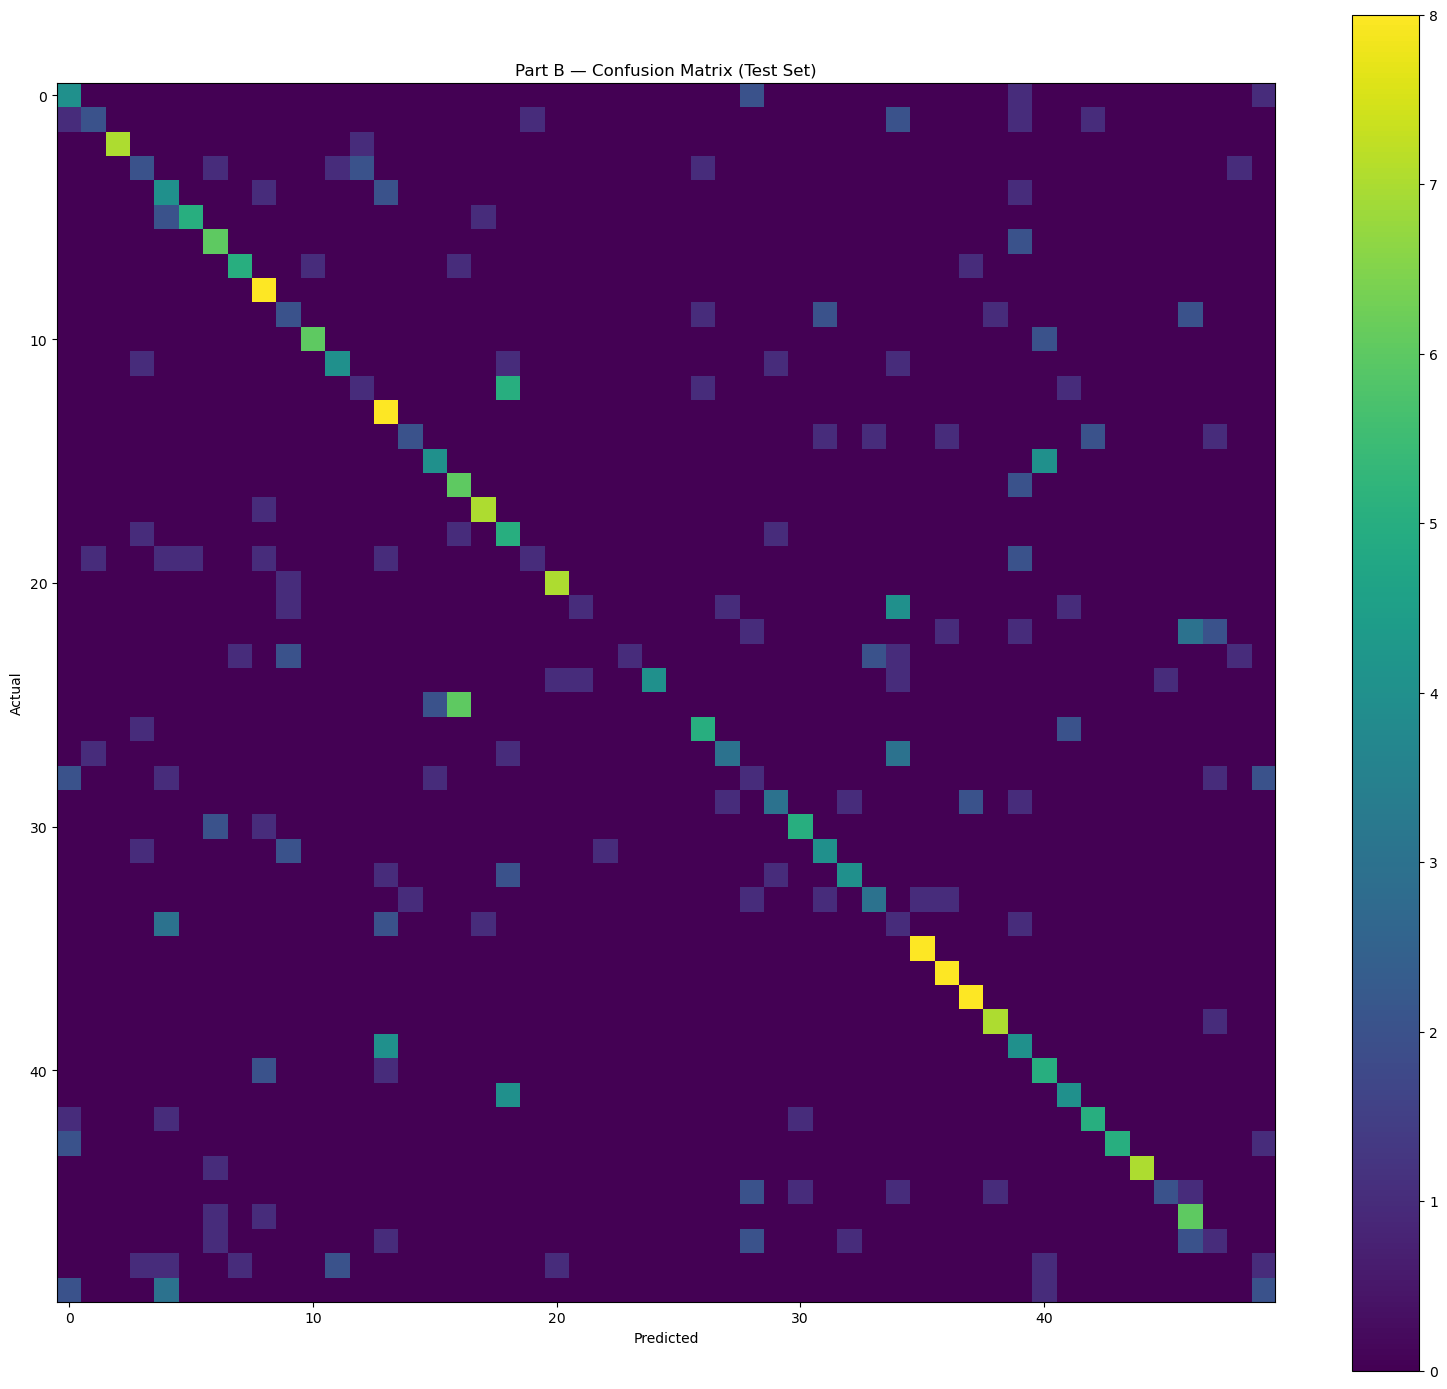

In [46]:
plt.figure(figsize=(16, 14))
plt.imshow(results_B["cm"], cmap="viridis")
plt.title("Part B — Confusion Matrix (Test Set)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.colorbar()
plt.tight_layout()
plt.savefig("stepB10_confusion_matrix.png", dpi=150)
plt.show()

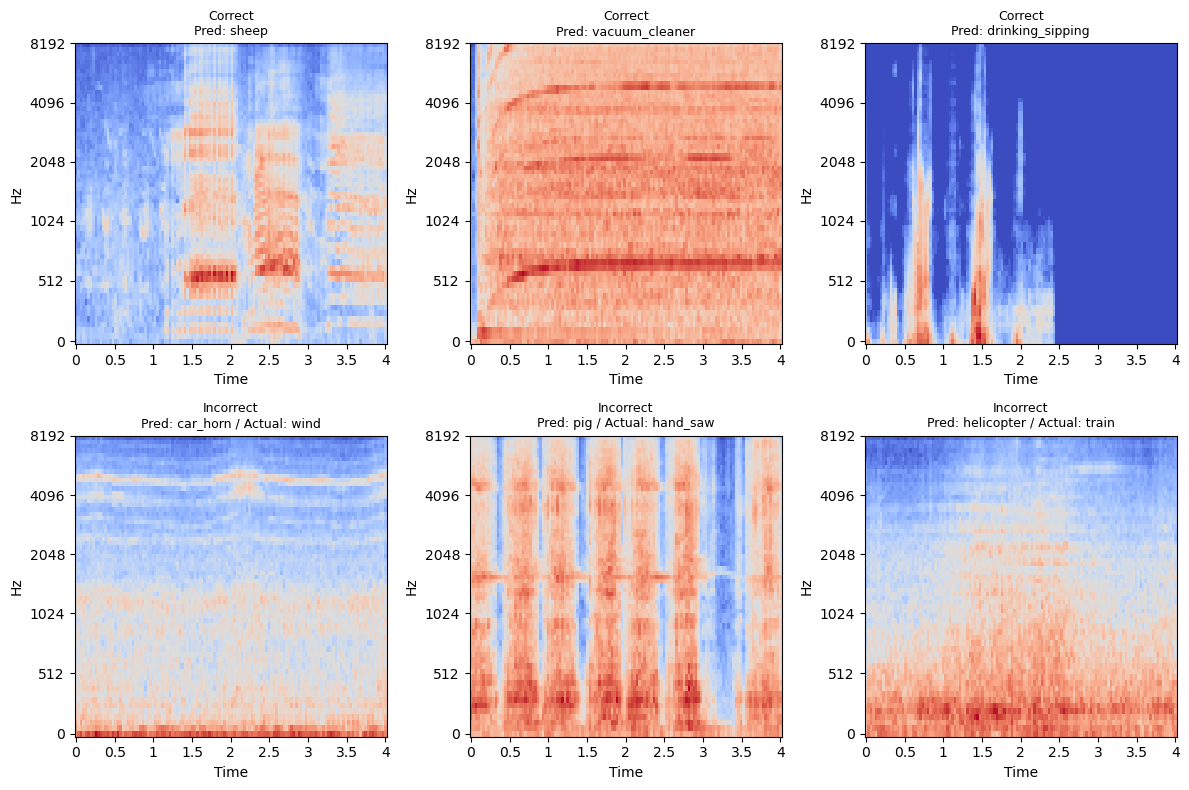

In [47]:
results_B["report_df"].to_csv("stepB10_classification_report.csv")
show_predictions(results_B, idx_to_label, tag="B")

### Final Comparison: Part A vs Part B

In [48]:
gap_A = history_A["train_acc"][-1] - history_A["val_acc"][-1]
gap_B = history_B["train_acc"][-1] - history_B["val_acc"][-1]

In [49]:
comparison = pd.DataFrame({
    "Metric": ["Test Accuracy", "Macro Precision", "Macro Recall",
               "Macro F1-score", "Final Train-Val Accuracy Gap"],
    "Part A (No Augmentation)": [
        results_A["accuracy"], results_A["precision"], results_A["recall"],
        results_A["f1"], gap_A
    ],
    "Part B (SpecAugment)": [
        results_B["accuracy"], results_B["precision"], results_B["recall"],
        results_B["f1"], gap_B
    ],
})
comparison["Improvement (B - A)"] = comparison["Part B (SpecAugment)"] - comparison["Part A (No Augmentation)"]
print(comparison.to_string(index=False))
comparison.to_csv("final_comparison_table.csv", index=False)

                      Metric  Part A (No Augmentation)  Part B (SpecAugment)  Improvement (B - A)
               Test Accuracy                  0.552500              0.507500            -0.045000
             Macro Precision                  0.593254              0.529910            -0.063344
                Macro Recall                  0.552500              0.507500            -0.045000
              Macro F1-score                  0.528093              0.486453            -0.041640
Final Train-Val Accuracy Gap                  0.171667             -0.011667            -0.183333


In [50]:
# Per-class F1 change: which classes improved / worsened most under SpecAugment
per_class_A = results_A["report_df"][["f1-score"]].rename(columns={"f1-score": "f1_A"})
per_class_B = results_B["report_df"][["f1-score"]].rename(columns={"f1-score": "f1_B"})
per_class_compare = per_class_A.join(per_class_B, how="inner")
per_class_compare = per_class_compare.drop(index=["accuracy", "macro avg", "weighted avg"], errors="ignore")
per_class_compare["delta"] = per_class_compare["f1_B"] - per_class_compare["f1_A"]
per_class_compare = per_class_compare.sort_values("delta", ascending=False)

In [51]:
print("Top 5 classes that IMPROVED most with SpecAugment:")
print(per_class_compare.head(5))
print("\nTop 5 classes that WORSENED most with SpecAugment:")
print(per_class_compare.tail(5))
per_class_compare.to_csv("final_per_class_f1_comparison.csv")

Top 5 classes that IMPROVED most with SpecAugment:
                   f1_A      f1_B     delta
laughing       0.266667  0.571429  0.304762
sneezing       0.222222  0.500000  0.277778
airplane       0.125000  0.400000  0.275000
pouring_water  0.700000  0.941176  0.241176
fireworks      0.000000  0.222222  0.222222

Top 5 classes that WORSENED most with SpecAugment:
                  f1_A      f1_B     delta
engine        0.285714  0.000000 -0.285714
church_bells  1.000000  0.695652 -0.304348
siren         0.800000  0.476190 -0.323810
coughing      0.521739  0.166667 -0.355072
frog          0.666667  0.000000 -0.666667
